In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import seaborn as sns

df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [6]:
##Data Cleaning
# Remove invalid values (if any)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

df = df.drop_duplicates()

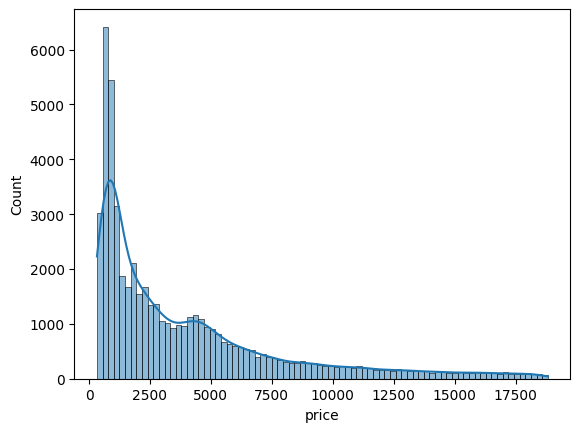

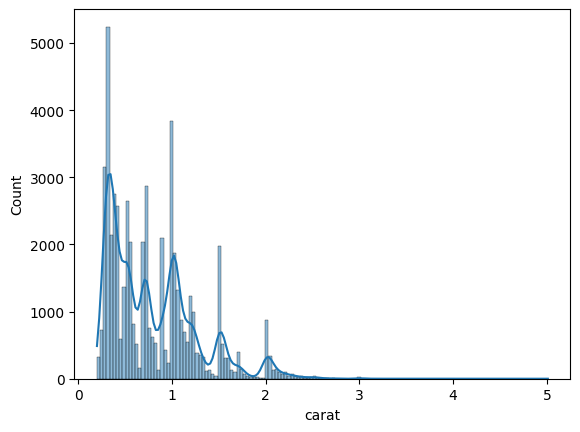

In [7]:
##Basic Visualizations
##Distribution

sns.histplot(df['price'], kde=True)
plt.show()

sns.histplot(df['carat'], kde=True)
plt.show()

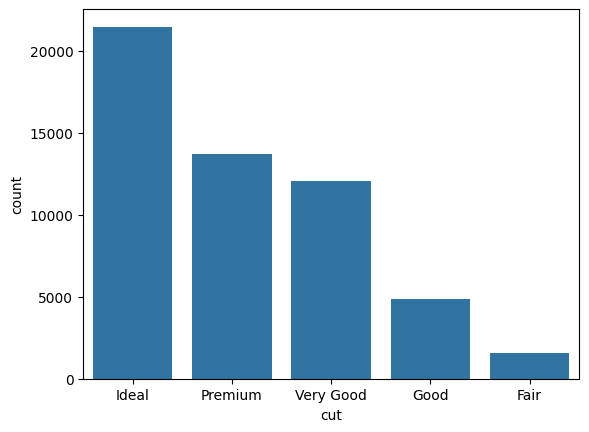

In [8]:
##Categorial Count
sns.countplot(x='cut', data=df)
plt.show()

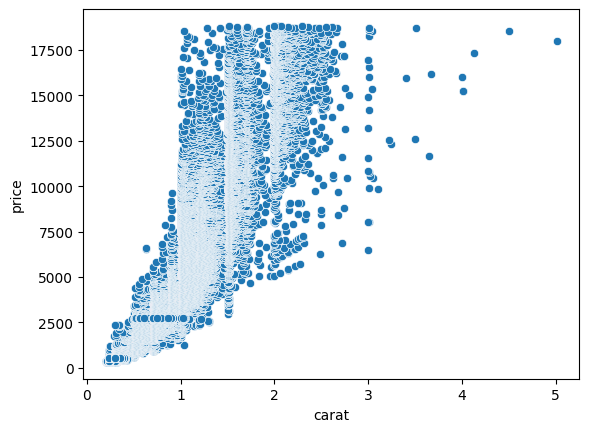

In [9]:
## Relationships
##Scatter plot
sns.scatterplot(x='carat', y='price', data=df)
plt.show()

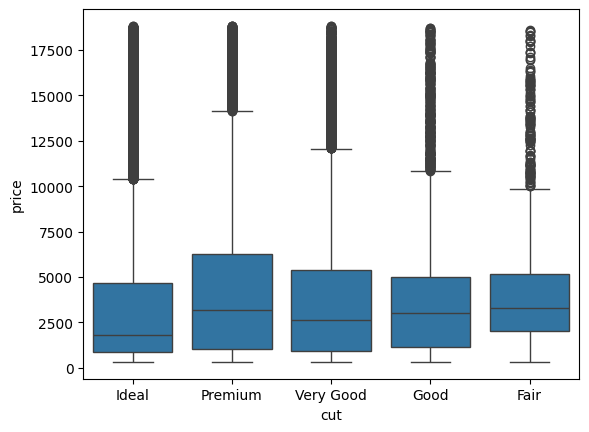

In [10]:
##Boxplot
sns.boxplot(x='cut', y='price', data=df)
plt.show()

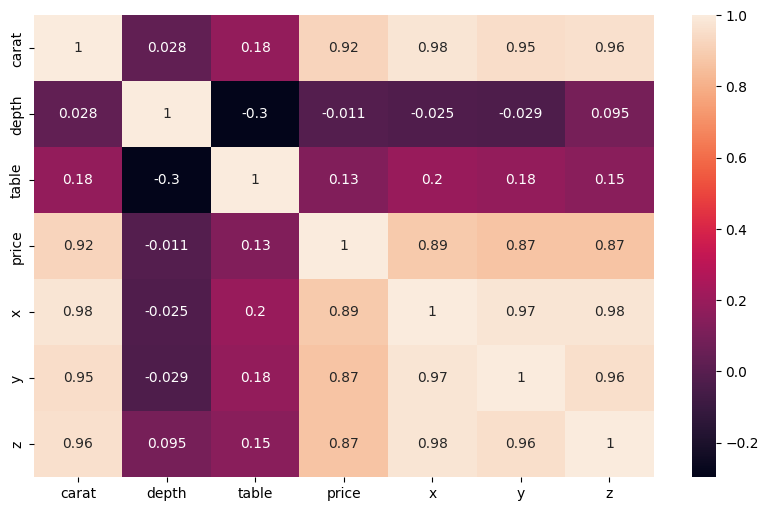

In [11]:
##Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [12]:
##Sprint 1: Preprocessing
##Encoding Categorical Data

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['cut'] = le.fit_transform(df['cut'])
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])

In [13]:
##Feature & Target Split
X = df.drop('price', axis=1)
y = df['price']

In [14]:
##Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
##Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
##Sprint 2: Model Development
##1. Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [17]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
##Evaluation
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

print("Linear Regression:")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest:")
evaluate(y_test, y_pred_rf)

Linear Regression:
RMSE: 1342.7400769728802
R2 Score: 0.8859125252927593

Random Forest:
RMSE: 532.3091844906203
R2 Score: 0.9820699300741325


In [20]:
##Sprint 3: Deployment
import pickle

pickle.dump(rf, open('diamond_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [21]:
##Prediction Script
model = pickle.load(open('diamond_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

sample = [[0.5, 3, 4, 2, 61.5, 55, 5.1, 5.0, 3.2]]  # example
sample = scaler.transform(sample)

prediction = model.predict(sample)
print("Predicted Price:", prediction)

Predicted Price: [1151.96666667]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Summary
*  Performed EDA to
understand distribution and relationships
*  Found carat strongly impacts price
*  Applied preprocessing (encoding + scaling)
*  Trained models:
1.  Linear Regression

2.  Random Forest

*  Random Forest achieved better performance (higher R², lower RMSE)
*  Model deployed using pickle for predictions